# `FlukaDecay` — radioactive-decay interface

This notebook demonstrates chromo's `FlukaDecay` class: a kinematics-free
wrapper around FLUKA 2025.1's nuclear-decay machinery. It covers:

1. **Catalog query** — every isotope/isomer in FLUKA's decay-data table, with
   filters on lifetime, mass number, atomic number.
2. **Isotope inspection** — pretty-printed table of mass, decay channels,
   gamma/alpha/CE/beta lines, etc.
3. **Inclusive decay sampling** — generate `N` correlated decay events for
   any isotope; products land in the standard chromo `EventData` arrays.
4. **Decay chains** — recursively decay daughters until all products are in
   a user-supplied set of allowed final-state particles.

**Prerequisites.** FLUKA 2025.1 must be installed and `$FLUPRO` set; chromo
must be built with `"fluka"` enabled (see `CLAUDE.md` § FLUKA integration).

**Single-instantiation.** FLUKA's library has process-global state. You can
construct **one** `FlukaDecay` per Python process; if a `Fluka` generator is
already alive, `FlukaDecay()` re-uses its init.

**Units.** chromo's `EventData` stores energies and momenta in **GeV**; this
notebook converts to MeV explicitly when plotting nuclear-decay quantities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from chromo.models import FlukaDecay, DecayChainHandler, STABLE_DEFAULT

# chromo standard: GeV.  Convert to MeV for nuclear-decay quantities:
GEV_TO_MEV = 1000.0
M_E_GEV    = 0.000510999  # electron rest mass

dcy = FlukaDecay(seed=42)

## 1. Catalog query

`FlukaDecay.catalog()` returns every isotope FLUKA can decay-sample.
First call materialises the full list (~4 500 entries) and caches it; subsequent
calls just filter the cache.

In [2]:
full = dcy.catalog()
print(f"Total nuclides with decay data: {len(full)}")

n_gs   = sum(1 for i in full if i.m == 0)
n_isom = sum(1 for i in full if i.m >  0)
print(f"  ground states  : {n_gs}")
print(f"  isomers (m>=1) : {n_isom}")

Total nuclides with decay data: 4478
  ground states  : 3292
  isomers (m>=1) : 1186


### Filter by lifetime

All isotopes with `T1/2 < 1 s` (a quick way to find short-lived radionuclides).

In [3]:
very_short = dcy.catalog(t_half_max=1.0, t_half_min=1e-6)
print(f"{len(very_short)} isotopes with 1 us < T1/2 < 1 s")
print("\nFirst 10 (shortest first):")
for iso in sorted(very_short, key=lambda i: i.t_half)[:10]:
    print(f"  {iso.short()}")

1538 isotopes with 1 us < T1/2 < 1 s

First 10 (shortest first):
  Si38 (Z=14, m=0): T1/2=1.000e-06 s, ExM=-4.170 MeV
  Nb90m3 (Z=41, m=3): T1/2=1.000e-06 s, ExM=-82.490 MeV
  Cs122m1 (Z=55, m=1): T1/2=1.000e-06 s, ExM=-78.099 MeV
  Cs126m1 (Z=55, m=1): T1/2=1.000e-06 s, ExM=-84.078 MeV
  Eu144m1 (Z=63, m=1): T1/2=1.000e-06 s, ExM=-74.492 MeV
  Nd154m2 (Z=60, m=2): T1/2=1.000e-06 s, ExM=-64.231 MeV
  Ir165 (Z=77, m=0): T1/2=1.000e-06 s, ExM=-11.595 MeV
  Au183m1 (Z=79, m=1): T1/2=1.000e-06 s, ExM=-30.118 MeV
  Au183m2 (Z=79, m=2): T1/2=1.000e-06 s, ExM=-29.961 MeV
  Pt191m1 (Z=78, m=1): T1/2=1.000e-06 s, ExM=-35.598 MeV


### Filter by `(A, Z)` range

Long-lived actinides — the kind of isotope you might query when designing a
shielding study or investigating a contamination scenario.

In [4]:
long_actinides = dcy.catalog(z_min=89, z_max=99, t_half_min=1e6)
print(f"{len(long_actinides)} actinides with T1/2 > 1e6 s (~ 12 d):\n")
for iso in sorted(long_actinides, key=lambda i: -i.t_half)[:15]:
    yr = iso.t_half / 3.15576e7
    tag = f"{yr:.2e} yr" if yr > 1.0 else f"{iso.t_half:.2e} s"
    print(f"  {iso.symbol}{iso.A:<3d} (Z={iso.Z:3d}, m={iso.m})  T1/2 = {tag}")

55 actinides with T1/2 > 1e6 s (~ 12 d):

  Th232 (Z= 90, m=0)  T1/2 = 1.40e+10 yr
  U238 (Z= 92, m=0)  T1/2 = 4.47e+09 yr
  U235 (Z= 92, m=0)  T1/2 = 7.04e+08 yr
  Pu244 (Z= 94, m=0)  T1/2 = 8.13e+07 yr
  U236 (Z= 92, m=0)  T1/2 = 2.34e+07 yr
  Cm247 (Z= 96, m=0)  T1/2 = 1.56e+07 yr
  Np237 (Z= 93, m=0)  T1/2 = 2.14e+06 yr
  Pu242 (Z= 94, m=0)  T1/2 = 3.75e+05 yr
  Cm248 (Z= 96, m=0)  T1/2 = 3.48e+05 yr
  U234 (Z= 92, m=0)  T1/2 = 2.45e+05 yr
  U233 (Z= 92, m=0)  T1/2 = 1.59e+05 yr
  Np236 (Z= 93, m=0)  T1/2 = 1.53e+05 yr
  Th230 (Z= 90, m=0)  T1/2 = 7.54e+04 yr
  Pa231 (Z= 91, m=0)  T1/2 = 3.28e+04 yr
  Pu239 (Z= 94, m=0)  T1/2 = 2.41e+04 yr


## 2. On-demand isotope inspection

`FlukaDecay.lookup` accepts isotope **names** (`"Cs137"`, `"Tc99m"`,
`"U238m1"`), `(A, Z, m)` **tuples**, or PDG **ion codes** (`10LZZZAAAI`).

`print(iso)` produces a DCYPRN-style table with channels, gammas, alphas,
CE/Auger lines, and beta spectra (all fetched lazily on first access).

In [5]:
print(dcy.lookup("Cs137"))

Isotope Cs137  (A=137, Z=55, m=0)
  T1/2     = 9.492e+08 s
  ExMass   = -86.5458 MeV
  J        = 3.5  parity = +
  Channels:
    B-     BR= 94.699%  -> 137/ 56/m1  Q=0.5140 MeV
    B-     BR=  5.301%  -> 137/ 56/m0  Q=1.1756 MeV
  Gamma lines (1):
    E=  0.03219 MeV  BR=  0.004%
  CE/Auger lines (1):
    E=  0.62422 MeV  BR=  0.006%
  Beta+/- spectra (2):
    E=  0.51397 MeV  BR= 94.700%
    E=  1.17563 MeV  BR=  5.300%


In [6]:
# Same isotope queried different ways:
print(dcy.lookup(137, 55, 0).short())   # tuple form
print(dcy.lookup(1000551370).short())    # PDG ion code

Cs137 (Z=55, m=0): T1/2=9.492e+08 s, ExM=-86.546 MeV
Cs137 (Z=55, m=0): T1/2=9.492e+08 s, ExM=-86.546 MeV


Ba-137m1 — the metastable daughter of Cs-137 — is where FLUKA stores the
famous 661.66 keV calibration line.

In [7]:
print(dcy.lookup("Ba137m"))

Isotope Ba137m1  (A=137, Z=56, m=1)
  T1/2     = 1.531e+02 s
  ExMass   = -87.0597 MeV
  J        = 5.5  parity = -
  Channels:
    IT     BR=100.000%  -> 137/ 56/m0  Q=0.6617 MeV
  Gamma lines (7):
    E=  0.00447 MeV  BR=  0.970%
    E=  0.03182 MeV  BR=  2.100%
    E=  0.03219 MeV  BR=  3.840%
    E=  0.03630 MeV  BR=  0.367%
    E=  0.03638 MeV  BR=  0.709%
    E=  0.03725 MeV  BR=  0.224%
    E=  0.66166 MeV  BR= 89.900%
  CE/Auger lines (7):
    E=  0.00367 MeV  BR=  7.820%
    E=  0.02640 MeV  BR=  0.820%
    E=  0.62422 MeV  BR=  8.220%
    E=  0.65567 MeV  BR=  1.482%
    E=  0.66036 MeV  BR=  0.317%
    E=  0.66140 MeV  BR=  0.068%
    E=  0.66164 MeV  BR=  0.010%


Direct access to the channel/line dataclasses for programmatic use.

In [8]:
u238 = dcy.lookup("U238")
for ch in u238.channels:
    print(f"{ch.name:<6s}  BR = {ch.branching*100:8.4f}%   "
          f"daughter = (A={ch.daughter_A}, Z={ch.daughter_Z}, m={ch.daughter_m})  "
          f"Q = {ch.q_value:.3f} MeV")

alpha   BR =  99.9999%   daughter = (A=234, Z=90, m=0)  Q = 4.270 MeV
SF      BR =   0.0001%   daughter = (A=-1, Z=-1, m=-1)  Q = 0.000 MeV


## 3. Inclusive decay sampling

`dcy(parent, n=N)` is a generator yielding `N` `EventData` objects.
FLUKA's branching ratios drive the channel mix; users do not pick the channel.
Each event has the standard chromo arrays: `pid`, `px/py/pz/en/m`, `status`,
`mothers`, `charge`, etc.

Below: 5 000 Cs-137 decays. Cs-137 is pure β⁻ to Ba-137 (mostly via the
metastable Ba-137m intermediate); each event has an electron, an antineutrino,
and ~95 % of the time a 661.66 keV gamma.

In [9]:
PDG_ELECTRON = 11
PDG_GAMMA    = 22

n_events = 5_000
electron_KE_MeV = []
gamma_E_MeV     = []
n_with_gamma = 0

for ev in dcy("Cs137", n=n_events):
    final = ev.status == 1                          # final-state mask
    pid_f = ev.pid[final]
    en_f  = ev.en[final]                            # total energy in GeV
    for p, e_gev in zip(pid_f, en_f):
        if int(p) == PDG_ELECTRON:
            electron_KE_MeV.append((float(e_gev) - M_E_GEV) * GEV_TO_MEV)
        elif int(p) == PDG_GAMMA:
            gamma_E_MeV.append(float(e_gev) * GEV_TO_MEV)
    if PDG_GAMMA in pid_f:
        n_with_gamma += 1

print(f"Events: {n_events}")
print(f"Events with at least one gamma: {n_with_gamma} "
      f"({100 * n_with_gamma / n_events:.1f} %)  -- expect ~94.7 %")
print(f"Mean e- kinetic energy: {np.mean(electron_KE_MeV):.3f} MeV  -- expect ~0.18")

Events: 5000
Events with at least one gamma: 4779 (95.6 %)  -- expect ~94.7 %
Mean e- kinetic energy: 0.170 MeV  -- expect ~0.18


Plot the electron and gamma spectra:

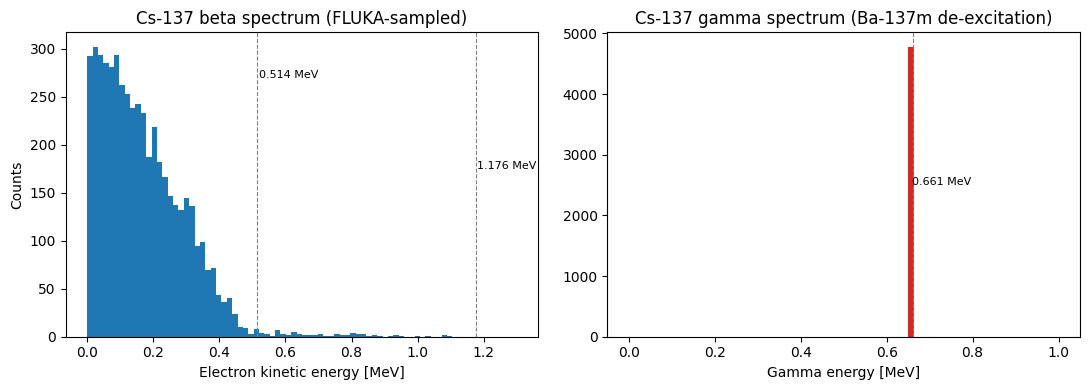

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(electron_KE_MeV, bins=80, range=(0, 1.3), color="#1f77b4")
axes[0].set_xlabel("Electron kinetic energy [MeV]")
axes[0].set_ylabel("Counts")
axes[0].set_title("Cs-137 beta spectrum (FLUKA-sampled)")
axes[0].axvline(0.514, ls="--", color="gray", lw=0.8)
axes[0].axvline(1.176, ls="--", color="gray", lw=0.8)
axes[0].text(0.52, axes[0].get_ylim()[1]*0.85, "0.514 MeV", fontsize=8)
axes[0].text(1.18, axes[0].get_ylim()[1]*0.55, "1.176 MeV", fontsize=8)

axes[1].hist(gamma_E_MeV, bins=80, range=(0, 1.0), color="#d62728")
axes[1].set_xlabel("Gamma energy [MeV]")
axes[1].set_title("Cs-137 gamma spectrum (Ba-137m de-excitation)")
axes[1].axvline(0.66166, ls="--", color="gray", lw=0.8)
axes[1].text(0.66, axes[1].get_ylim()[1]*0.5, "0.661 MeV", fontsize=8)

fig.tight_layout()
plt.show()

### A more interesting example: Co-60

Co-60 → Ni-60 + 2 γ-rays (1.17 + 1.33 MeV). The two-gamma cascade should be
visible in the gamma spectrum.

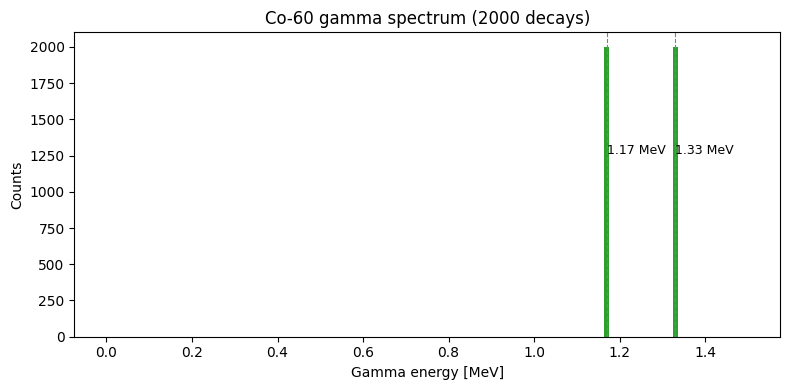

In [11]:
co60_gammas_MeV = []
for ev in dcy("Co60", n=2_000):
    final = ev.status == 1
    co60_gammas_MeV.extend(
        float(e_gev) * GEV_TO_MEV
        for p, e_gev in zip(ev.pid[final], ev.en[final])
        if int(p) == PDG_GAMMA
    )

plt.figure(figsize=(8, 4))
plt.hist(co60_gammas_MeV, bins=120, range=(0, 1.5), color="#2ca02c")
plt.axvline(1.17, ls="--", color="gray", lw=0.8)
plt.axvline(1.33, ls="--", color="gray", lw=0.8)
plt.text(1.17, plt.ylim()[1]*0.6, "1.17 MeV", fontsize=9)
plt.text(1.33, plt.ylim()[1]*0.6, "1.33 MeV", fontsize=9)
plt.xlabel("Gamma energy [MeV]")
plt.ylabel("Counts")
plt.title("Co-60 gamma spectrum (2000 decays)")
plt.tight_layout()
plt.show()

## 4. Decay chains

`FlukaDecay.chain(parent, n=N, final_state=...)` recursively decays any product
that is **not** in the user-supplied `final_state` set. Recursion stops when
all products are stable (in the set), have no decay data, or hit `max_depth`.

`STABLE_DEFAULT` is a precomputed set containing leptons, photons, free
nucleons, and every nuclide FLUKA marks as effectively stable
(`T1/2 ≥ 1e38 s`).

In [12]:
print(f"STABLE_DEFAULT contains {len(STABLE_DEFAULT)} PDG ids")
print(f"  ... including 22 (gamma): {22 in STABLE_DEFAULT}")
print(f"  ... including 1000260560 (Fe-56): {1_000_260_560 in STABLE_DEFAULT}")
print(f"  ... including 1000280600 (Ni-60): {1_000_280_600 in STABLE_DEFAULT}")

STABLE_DEFAULT contains 273 PDG ids
  ... including 22 (gamma): True
  ... including 1000260560 (Fe-56): True
  ... including 1000280600 (Ni-60): True


**Cs-137 chain.** With the default `final_state=STABLE_DEFAULT`, the chain
should always terminate on stable Ba-137 g.s. (PDG `1000561370`).

In [13]:
BA137_PDG = 1000561370
n_terminating = 0
n = 0
for ev in dcy.chain("Cs137", n=200):
    n += 1
    if BA137_PDG in ev.pid:
        n_terminating += 1

print(f"{n_terminating}/{n} Cs-137 chains terminate on stable Ba-137")

200/200 Cs-137 chains terminate on stable Ba-137


### Custom `final_state`: stop the chain early

Users can interrupt the chain at any nuclide they care about.  Here we add
Th-234 to the stop set, so a U-238 chain ends after the first α decay rather
than walking the full uranium series.

In [14]:
TH234_PDG = 1000902340
early_stop = STABLE_DEFAULT | {TH234_PDG}

with_th234 = 0
for ev in dcy.chain("U238", n=20, final_state=early_stop):
    if TH234_PDG in ev.pid:
        with_th234 += 1
print(f"{with_th234}/20 events end on Th-234 (chain interrupted after first alpha)")

20/20 events end on Th-234 (chain interrupted after first alpha)


### `max_depth` and `on_max_depth`

Long natural-decay series (e.g. U-238 → … → Pb-206, 14 steps) can be capped
via `max_depth`. The default raises `RuntimeError` on overflow; pass
`on_max_depth="warn"` to truncate the chain instead and emit a warning.

In [15]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    events = list(dcy.chain("U238", n=5, max_depth=2, on_max_depth="warn"))

for k, ev in enumerate(events):
    nuclei = [int(p) for p in ev.pid if abs(int(p)) >= 1_000_000_000]
    print(f"event {k}: {len(ev.pid)} products, nuclei present = {nuclei}")

event 0: 14 products, nuclei present = [1000922380, 1000020040, 1000922340]
event 1: 15 products, nuclei present = [1000922380, 1000020040, 1000922340]
event 2: 14 products, nuclei present = [1000922380, 1000020040, 1000922340]
event 3: 15 products, nuclei present = [1000922380, 1000020040, 1000922340]
event 4: 15 products, nuclei present = [1000922380, 1000020040, 1000922340]


## 5. Notes & caveats

* **Single instantiation per process.** FLUKA's library has process-global
  state. Tests in chromo's suite use `multiprocessing.Process` to side-step
  this; for interactive use, restart the kernel between configurations.
* **Coexistence with `Fluka`.** A `Fluka` hadronic generator and `FlukaDecay`
  share the FLUKA library init; whichever is constructed first does the work.
  `Fluka(post_event=DecayChainHandler(...).expand)` is wired up but currently
  blocked by an upstream FLUKA bug for β-emitters running after a hadronic
  event (FLUKA_QUESTIONS.md #6). The Python plumbing is correct and will
  start working once the upstream issue is fixed.
* **Some isotopes can't be sampled.** A small number of catalogued isotopes
  (notably Ac-228) return `LSUCCS=False` from FLUKA's `SPDCEV`; chains that
  hit them stall. Filed upstream as FLUKA_QUESTIONS.md #5.
* **`QRDDCY` is vendored.** chromo's `_fluka` extension ships a verbatim copy
  of FLUKA's `QRDDCY` Q-value routine because it's not exported by
  `libflukahp.a`. Re-sync on FLUKA bumps (FLUKA_QUESTIONS.md #4).